In [1]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import uuid
import json
import joblib

In [2]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [3]:
import warnings
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings("ignore", category=UserWarning)  # ignore all UserWarnings
# or more specific
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [4]:
drive.mount('/content/drive')
csv_path = "/content/drive/Shared drives/Gestió de Projectes/Projecte/refined_data/final_dataset.csv"

df = pd.read_csv(csv_path, sep=',', encoding='utf-8')
print(f"Data loaded from {csv_path}")

Mounted at /content/drive
Data loaded from /content/drive/Shared drives/Gestió de Projectes/Projecte/refined_data/final_dataset.csv


In [5]:
def prepare_data(df, target_col='CODI_ANOMALIA'):
    """
    Memory-efficient preprocessing for large datasets.
    - Treats all features (except target) as numeric.
    - Downcasts numeric columns to float32/int32 to save memory.
    - Encodes the target as labels (int32).
    - Returns: X_train, X_test, y_train, y_test, label_encoder, numeric_cols, cat_cols
    """
    le = LabelEncoder()
    y = le.fit_transform(df[target_col].astype(str)).astype('int32')

    X = df.drop(columns=[target_col])

    for col in X.select_dtypes(include=['int64']).columns:
        X[col] = pd.to_numeric(X[col], downcast='integer')
    for col in X.select_dtypes(include=['float64']).columns:
        X[col] = pd.to_numeric(X[col], downcast='float')

    return X, y, le

In [6]:
def plot_kmeans_subplots(cluster_table):
    """
    Creates seaborn subplots:
    One subplot per cluster, showing the count of each CODI_ANOMALIA inside that cluster.

    cluster_table must be the output from analyze_kmeans_clusters:
        rows = clusters
        columns = anomaly types
        values = counts
    """
    n_clusters = cluster_table.shape[0]
    n_cols = 4  # number of plots per row
    n_rows = (n_clusters + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
    axes = axes.flatten()

    for i, (cluster_id, row) in enumerate(cluster_table.iterrows()):
        ax = axes[i]
        sns.barplot(
            x=row.index,
            y=row.values,
            ax=ax
        )
        ax.set_title(f"Cluster {cluster_id}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        ax.set_ylabel("Count")
        ax.set_xlabel("CODI_ANOMALIA")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


In [7]:
def evaluate_kmeans_cluster_quality(df_analysis):
    """
    Given a DataFrame with columns:
      - cluster
      - anomalia (string names)

    Returns:
      A score measuring how well clusters align with anomaly labels.
    """

    # Count how many of each anomaly appears in each cluster
    table = df_analysis.groupby(["cluster", "anomalia"]).size().unstack(fill_value=0)

    # Score per anomaly:
    # For each anomaly: largest cluster count / total samples of that anomaly
    scores = []
    for anomaly in table.columns:
        anomaly_counts = table[anomaly]
        total = anomaly_counts.sum()
        if total == 0:
            continue
        best_cluster_count = anomaly_counts.max()
        score = best_cluster_count / total
        scores.append(score)

    # Final score = average among all anomalies
    return float(np.mean(scores)), table


def smart_kmeans_search(
    X,
    y,
    label_encoder,
    max_clusters=10,
    batch_size=10000,
    random_state=RANDOM_STATE,
    test_size=TEST_SIZE,
    top_n=3
):
    """
    Runs KMeans for k = 2 to max_clusters.
    For each k:
       - Trains MiniBatchKMeans
       - Predicts clusters on X_test
       - Computes cluster-label purity score

    Returns:
      A sorted list of the top scoring K configurations.
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    results = []

    # Convert y_test to string labels
    y_test_names = label_encoder.inverse_transform(y_test)

    print(f"Running KMeans search from 2 to {max_clusters} clusters...\n")

    for k in range(2, max_clusters + 1):
        print(f"Training KMeans with k={k}...")

        # Train model
        kmeans = MiniBatchKMeans(
            n_clusters=k,
            batch_size=batch_size,
            random_state=random_state
        )
        kmeans.fit(X_train)

        # Predict on test set
        clusters = kmeans.predict(X_test)

        # Build dataframe for evaluation
        df_analysis = pd.DataFrame({
            "cluster": clusters,
            "anomalia": y_test_names
        })

        # Compute score
        score, count_table = evaluate_kmeans_cluster_quality(df_analysis)

        print(f"  Score for k={k}: {score:.4f}")

        # Save results
        results.append({
            "k": k,
            "score": score,
            "kmeans_model": kmeans,
            "cluster_table": count_table
        })

    print("\nKMeans search complete. Sorting results...\n")

    # Sort by score descending
    results_sorted = sorted(results, key=lambda x: x["score"], reverse=True)

    # Return top N
    return results_sorted[:top_n]

In [8]:
def split_data_by_kmeans_clusters(X, y, label_encoder, top_score_entry):
    """
    Splits the dataset into clusters based on an already trained KMeans model.

    Parameters
    ----------
    X : pd.DataFrame or np.ndarray
        Feature matrix.
    y : array-like
        Encoded target labels.
    label_encoder : LabelEncoder
        The encoder used to transform y into integers.
    top_score_entry : dict
        One of the results produced by smart_kmeans_search, containing:
        - "kmeans_model": trained MiniBatchKMeans
        - "k": number of clusters

    Returns
    -------
    clusters_list : list of dicts
        [
          {
            "cluster_id": int,
            "X_cluster": X rows belonging to that cluster,
            "y_cluster": encoded y values,
            "y_cluster_names": decoded labels,
          },
          ...
        ]
    """

    model = top_score_entry["kmeans_model"]
    k = top_score_entry["k"]

    # Predict cluster assignment for all data
    cluster_labels = model.predict(X)

    clusters_list = []

    for cluster_id in range(k):
        # Select rows belonging to this cluster
        mask = (cluster_labels == cluster_id)

        X_cluster = X[mask]
        y_cluster = y[mask]
        y_cluster_names = label_encoder.inverse_transform(y_cluster)

        clusters_list.append({
            "cluster_id": cluster_id,
            "X_cluster": X_cluster,
            "y_cluster": y_cluster,
            "y_cluster_names": y_cluster_names
        })

    return clusters_list


In [9]:
def build_recursive_kmeans_tree(
    X,
    y,
    label_encoder,
    max_clusters=5,
    batch_size=10000,
    random_state=42,
    test_size=0.2,
    min_samples_for_split=1_000_000,
    level=0
):
    """
    Recursively builds a tree of KMeans subclusters.
    Stops when:
        1. Dataset has fewer than min_samples_for_split samples
        2. Best KMeans result has only 1 cluster

    Returns a tree structure (dictionary).
    """

    n_samples = len(X)

    # ---------- STOP CONDITION 1 ----------
    if len(set(y))<=1:
        return {
            "level": level,
            "node_id": str(uuid.uuid4()),
            "n_samples": n_samples,
            "k": 1,
            "kmeans_model": model,
            "children": [],
            "stop_reason": "single_cluster",
            "data": (X, y),
            "set": set(y)
        }

    # ---------- STOP CONDITION 2 ----------
    if n_samples < min_samples_for_split:
        return {
            "level": level,
            "node_id": str(uuid.uuid4()),
            "n_samples": n_samples,
            "k": 1,
            "kmeans_model": None,
            "children": [],
            "stop_reason": "small_data",
            "data": (X, y),
            "set": set(y)
        }

    # ---------- RUN KMEANS SEARCH ----------
    results = smart_kmeans_search(
        X,
        y,
        label_encoder=label_encoder,
        max_clusters=max_clusters,
        top_n=1  # we only choose the best
    )

    best = results[0]
    k = best["k"]
    model = best["kmeans_model"]

    # ---------- CONTINUE SPLITTING ----------
    # Predict cluster assignments on the full dataset (not test only)
    cluster_labels = model.predict(X)

    # Build children nodes recursively
    children = []
    for cluster_id in range(k):
        mask = (cluster_labels == cluster_id)
        X_sub = X[mask]
        y_sub = y[mask]

        child = build_recursive_kmeans_tree(
            X_sub,
            y_sub,
            label_encoder,
            max_clusters=max_clusters,
            batch_size=batch_size,
            random_state=random_state,
            test_size=test_size,
            min_samples_for_split=min_samples_for_split,
            level=level + 1
        )
        children.append(child)

    # Internal node (no data stored here!)
    return {
        "level": level,
        "node_id": str(uuid.uuid4()),
        "n_samples": n_samples,
        "k": k,
        "kmeans_model": model,
        "children": children,
        "stop_reason": None,
        "data": None,
        "set": None
    }


In [10]:
def find_leaf_for_sample(tree, x_row):
    """
    Traverses the tree to find the leaf where this new sample falls.
    x_row: numpy array or single-row DataFrame
    """
    node = tree

    while True:
        # If leaf node → return leaf
        if node["children"] == []:
            return node

        model = node["kmeans_model"]
        k = node["k"]

        cluster_id = model.predict(x_row)[0]
        node = node["children"][cluster_id]


In [11]:
X, y, le = prepare_data(df)

In [12]:
X, X_valid, y, y_valid = train_test_split(
        X, y,
        test_size=0.05,
        random_state=RANDOM_STATE,
        stratify=y
    )

In [13]:
# Build the full multi-level structure
tree = build_recursive_kmeans_tree(
    X,
    y,
    label_encoder=le,
    max_clusters=5,
    min_samples_for_split=1_000_000
)


Running KMeans search from 2 to 5 clusters...

Training KMeans with k=2...
  Score for k=2: 0.9698
Training KMeans with k=3...
  Score for k=3: 0.7336
Training KMeans with k=4...
  Score for k=4: 0.7235
Training KMeans with k=5...
  Score for k=5: 0.6183

KMeans search complete. Sorting results...

Running KMeans search from 2 to 5 clusters...

Training KMeans with k=2...
  Score for k=2: 0.7415
Training KMeans with k=3...
  Score for k=3: 0.6652
Training KMeans with k=4...
  Score for k=4: 0.6256
Training KMeans with k=5...
  Score for k=5: 0.6097

KMeans search complete. Sorting results...

Running KMeans search from 2 to 5 clusters...

Training KMeans with k=2...
  Score for k=2: 0.9838
Training KMeans with k=3...
  Score for k=3: 0.7084
Training KMeans with k=4...
  Score for k=4: 0.6614
Training KMeans with k=5...
  Score for k=5: 0.6110

KMeans search complete. Sorting results...

Running KMeans search from 2 to 5 clusters...

Training KMeans with k=2...
  Score for k=2: 0.7170
T

In [18]:
def yesmen(tree, label_encoder):
    node = tree

    # If leaf node → plot
    if node["children"] == []:
        print(f"\nLeaf node id: {node['node_id']}")
        print(f"Leaf node stop reason: {node['stop_reason']}")
        print(f"Leaf node level: {node['level']}")
        print(f"Leaf node set: {node['set']}\n")

        X_leaf, y_leaf = node["data"]

        # Count categories
        unique, counts = np.unique(y_leaf, return_counts=True)
        labels = label_encoder.inverse_transform(unique)

        plt.figure(figsize=(8, 4))
        plt.bar(labels, counts, color='skyblue')
        plt.xlabel('Categories')
        plt.ylabel('Count')
        plt.title(f'Leaf Level {node["level"]} - Stop Reason: {node["stop_reason"]}')
        plt.xticks(rotation=45)
        plt.show()

    else:
        for child in node.get("children", []):
            yesmen(child, label_encoder)



Leaf node id: 39e70ff1-e4ca-4e26-aa38-3ed8f275e0c7
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(3), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(12), np.int32(15), np.int32(16)}



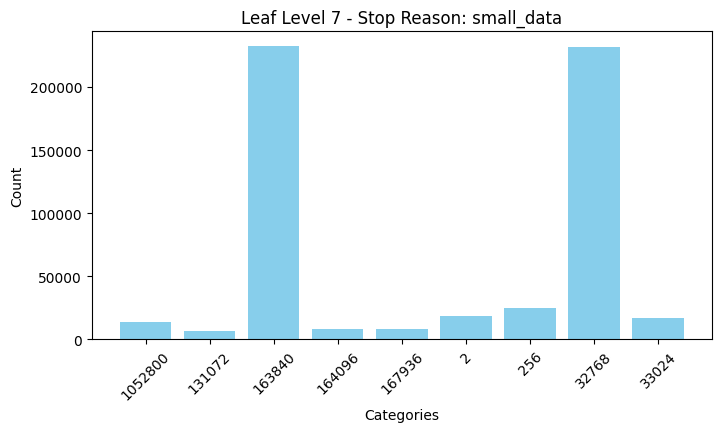


Leaf node id: 5162d10f-0fae-4f5c-a573-d92b56191f42
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(0), np.int32(2), np.int32(7), np.int32(8), np.int32(12), np.int32(15), np.int32(16)}



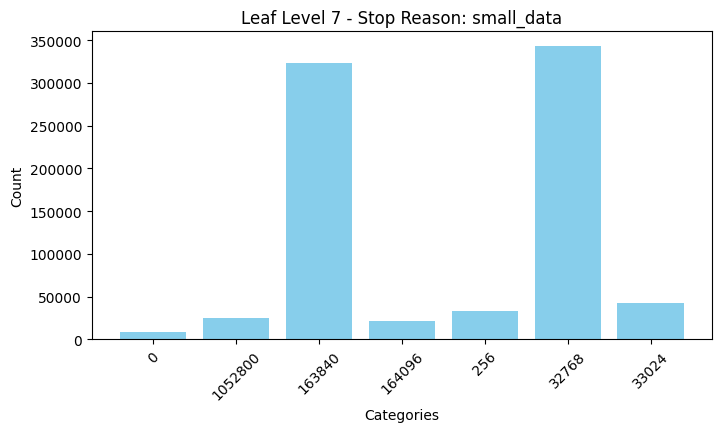


Leaf node id: e76e10bc-4080-417b-92e7-744e84ff8746
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(9), np.int32(12), np.int32(15), np.int32(16), np.int32(17)}



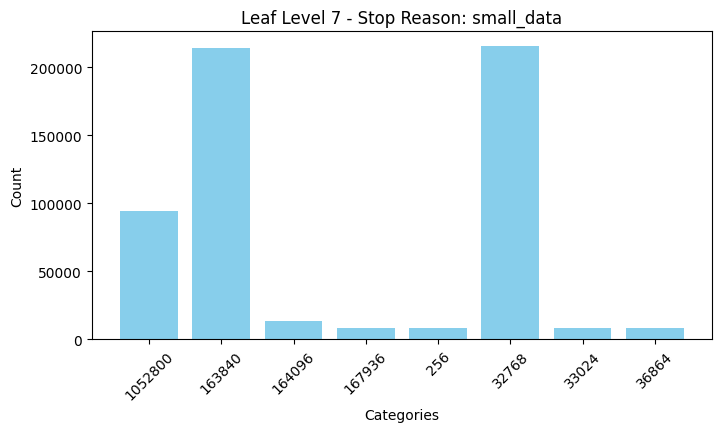


Leaf node id: 3217eb6d-9a09-4d65-ba4a-7d13b1bc5438
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(9), np.int32(13), np.int32(15), np.int32(16), np.int32(21), np.int32(23)}



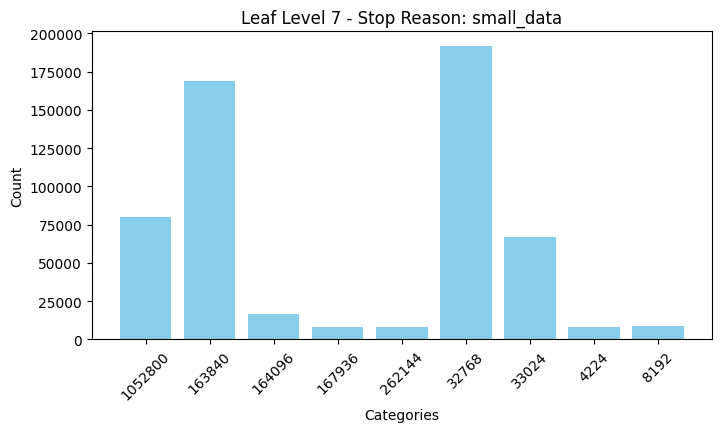


Leaf node id: 1e960e7f-65b4-4fc4-86da-f61b8575512a
Leaf node stop reason: small_data
Leaf node level: 5
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(9), np.int32(12), np.int32(13), np.int32(15), np.int32(16), np.int32(18), np.int32(23)}



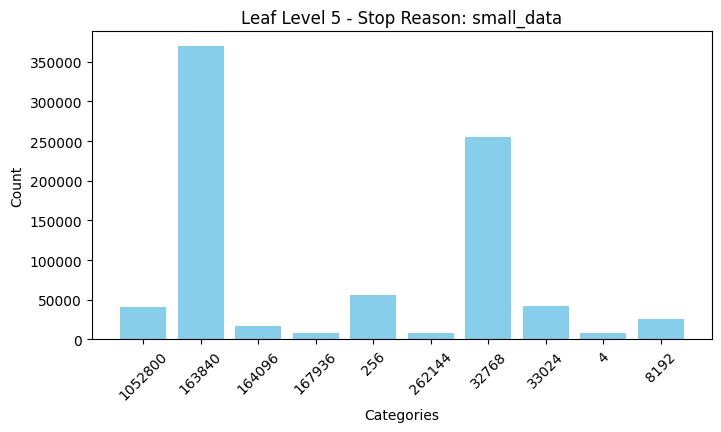


Leaf node id: 3dacd48f-b1b7-4a9d-9648-0031e190a151
Leaf node stop reason: small_data
Leaf node level: 8
Leaf node set: {np.int32(2), np.int32(3), np.int32(5), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(12), np.int32(15), np.int32(16), np.int32(23)}



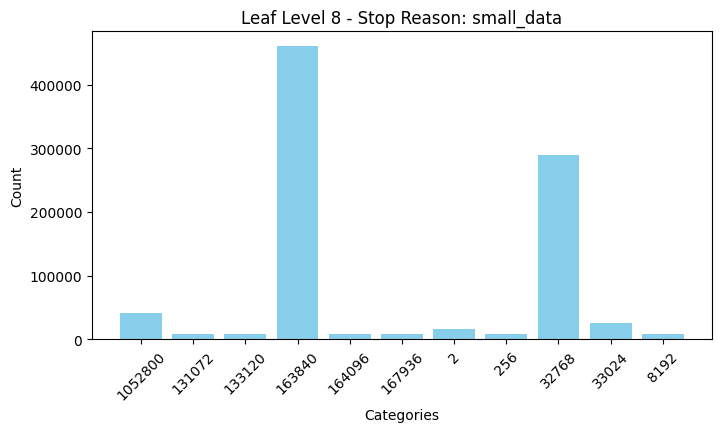


Leaf node id: f077bd1b-ce91-4869-b2e2-73d85e54778d
Leaf node stop reason: small_data
Leaf node level: 8
Leaf node set: {np.int32(2), np.int32(3), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(12), np.int32(13), np.int32(15), np.int32(16), np.int32(18)}



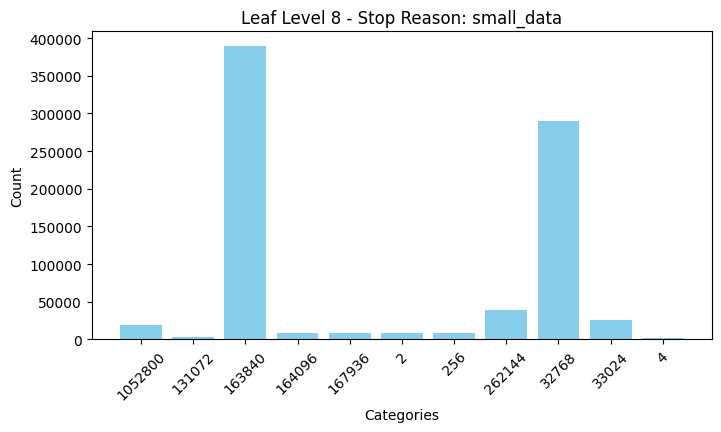


Leaf node id: 49d27f59-041a-4a93-b656-b0139bf752c2
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(7), np.int32(13), np.int32(15)}



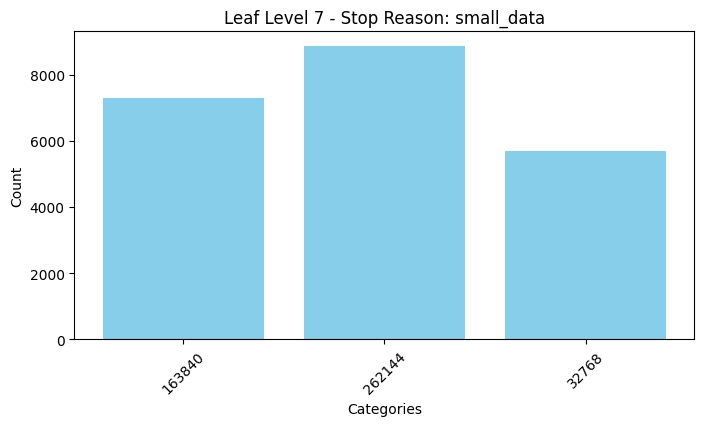


Leaf node id: 65a8af6c-26ef-4575-b89e-634f6ffcc010
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(12), np.int32(13), np.int32(15), np.int32(16)}



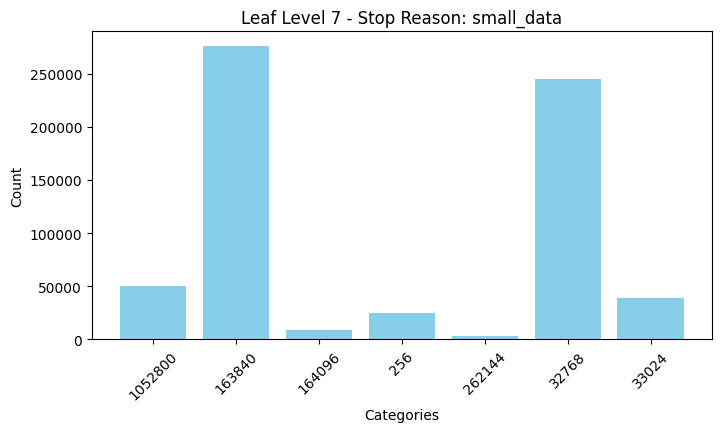


Leaf node id: 713913fc-b00a-4b9e-8188-0f4da3670475
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(9), np.int32(12), np.int32(15), np.int32(16)}



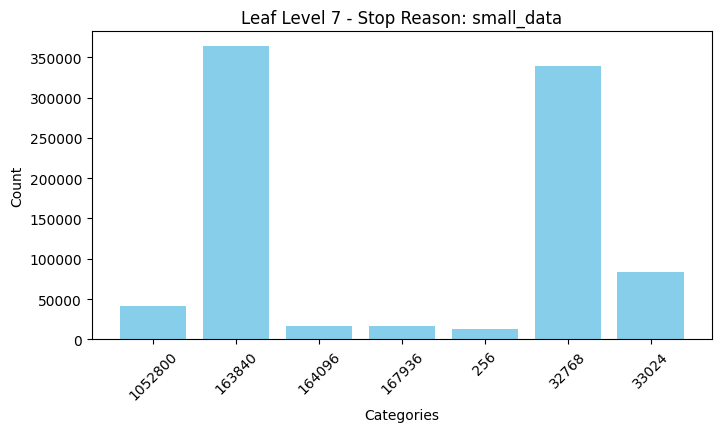


Leaf node id: 59781746-1b4b-4260-adb5-9f3502d2c68b
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(7), np.int32(8), np.int32(10), np.int32(12), np.int32(14), np.int32(15), np.int32(16), np.int32(17)}



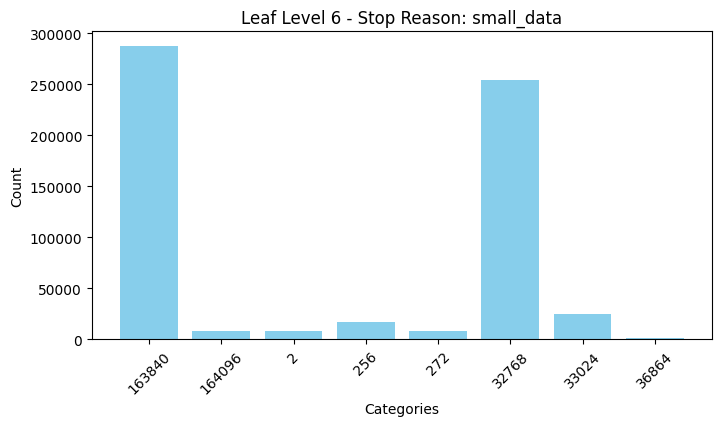


Leaf node id: 5f047ae8-cb78-4c14-9be3-43b3e8128c7e
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(11), np.int32(12), np.int32(15), np.int32(16), np.int32(21), np.int32(23)}



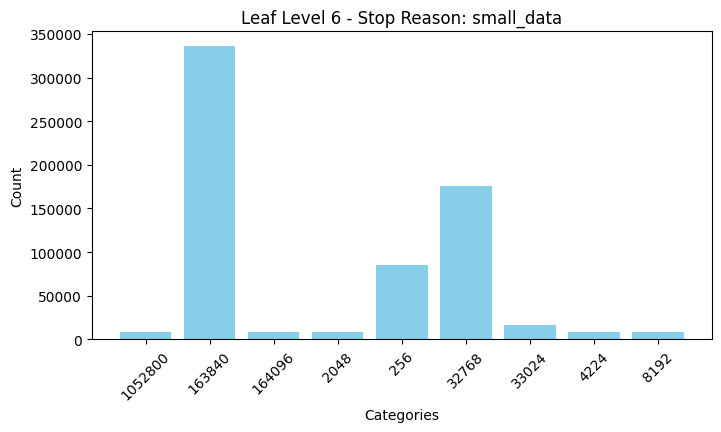


Leaf node id: 16f01a7d-67b8-42e0-b0ad-c690131d2276
Leaf node stop reason: small_data
Leaf node level: 3
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(13), np.int32(15), np.int32(16)}



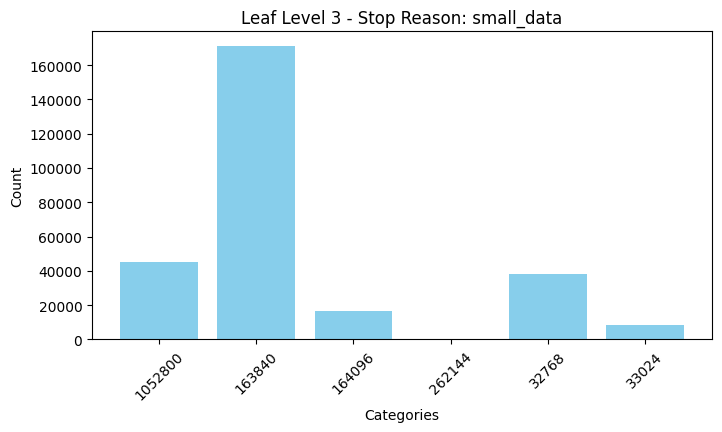


Leaf node id: e4ae9a44-6ae4-48f6-81f0-582f1f10990d
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(3), np.int32(4), np.int32(7), np.int32(9), np.int32(10), np.int32(12), np.int32(15), np.int32(16), np.int32(23)}



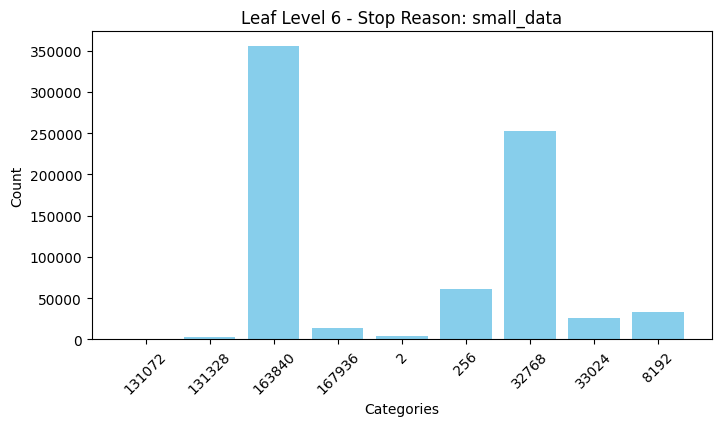


Leaf node id: 2eab28b4-58d1-4f18-9a67-54d2c877b314
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(12), np.int32(14), np.int32(15), np.int32(16), np.int32(23)}



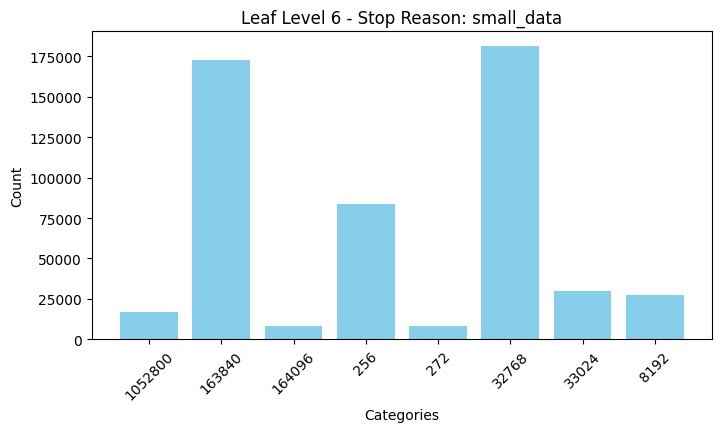


Leaf node id: bb083f78-b5a9-4b7c-a0ff-b41d23d8c207
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(7), np.int32(15)}



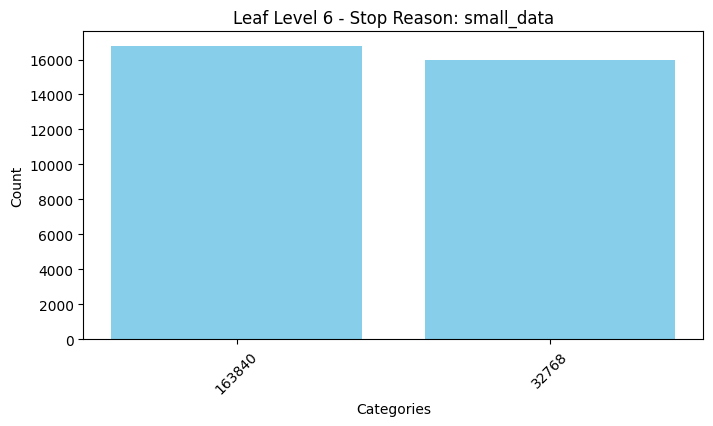


Leaf node id: c835e21c-d4d2-4df7-a211-00290d6eb3dc
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(10), np.int32(12), np.int32(14), np.int32(15), np.int32(16), np.int32(23)}



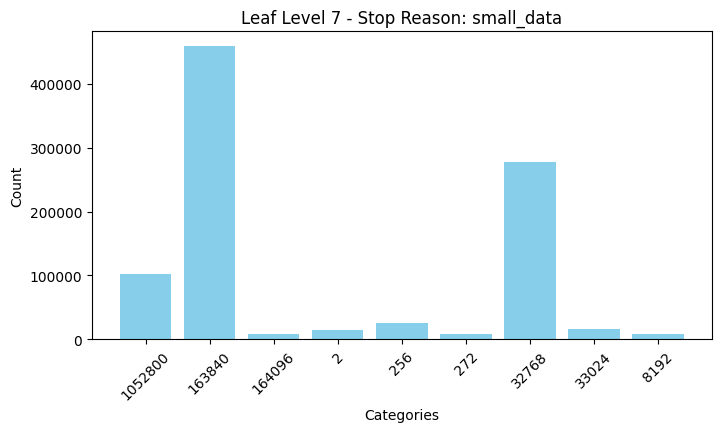


Leaf node id: efabb10f-d2dc-4b72-90f6-1e2a32080cb1
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(0), np.int32(2), np.int32(7), np.int32(9), np.int32(10), np.int32(12), np.int32(15), np.int32(16), np.int32(20)}



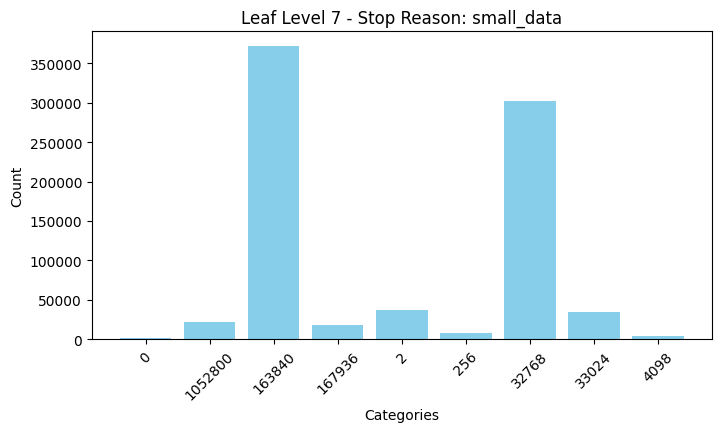


Leaf node id: ee34e71f-ac00-4c70-9733-298934e4f82c
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(7), np.int32(15)}



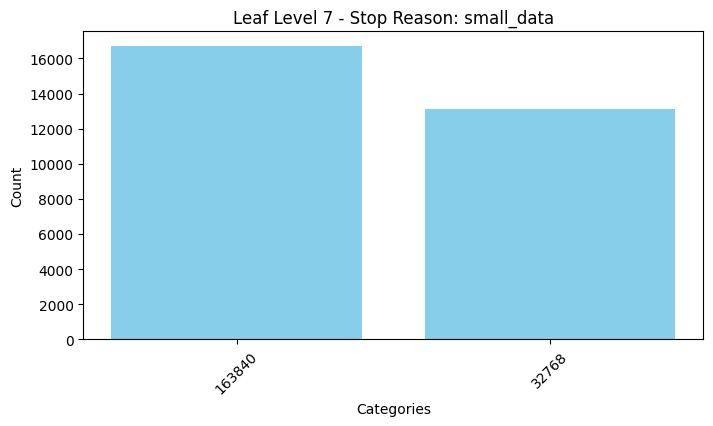


Leaf node id: 96574f47-3d0c-4a8d-9221-c20487f5ba63
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(9), np.int32(12), np.int32(15), np.int32(16), np.int32(23)}



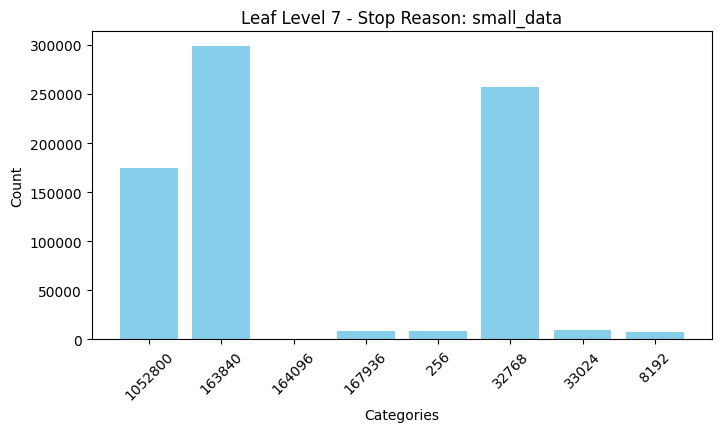


Leaf node id: 0d7d9c8c-d92d-4ae6-9e95-10c5987c3c60
Leaf node stop reason: small_data
Leaf node level: 9
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(12), np.int32(15), np.int32(16), np.int32(17)}



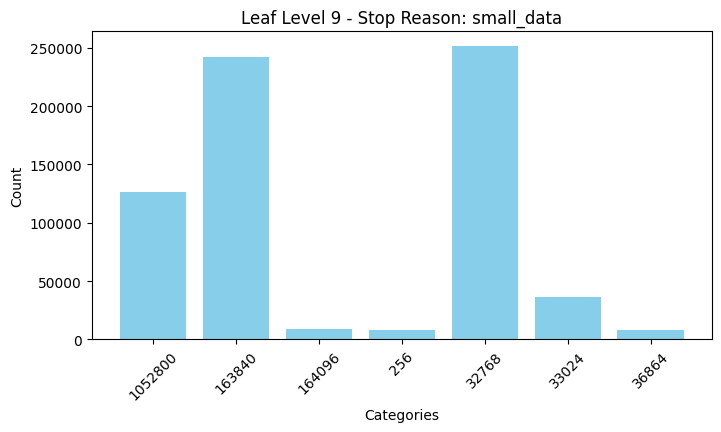


Leaf node id: e06cdeeb-903a-41ce-b99e-fda52e662470
Leaf node stop reason: small_data
Leaf node level: 9
Leaf node set: {np.int32(1), np.int32(2), np.int32(7), np.int32(8), np.int32(9), np.int32(15), np.int32(16), np.int32(18)}



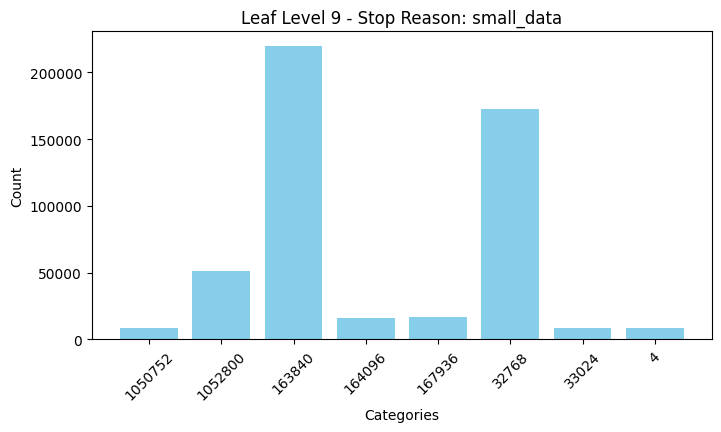


Leaf node id: ed2bd259-0008-451a-a195-51d212fe30a9
Leaf node stop reason: small_data
Leaf node level: 8
Leaf node set: {np.int32(15), np.int32(7)}



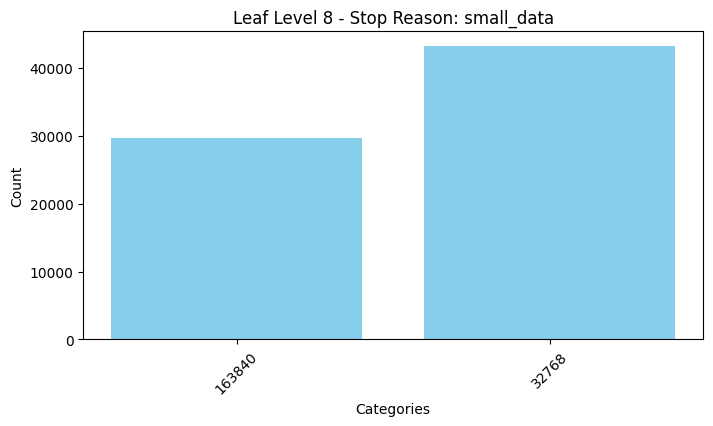


Leaf node id: db839bf4-6471-41cb-9e12-96124093df4b
Leaf node stop reason: small_data
Leaf node level: 4
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(12), np.int32(15), np.int32(16), np.int32(23)}



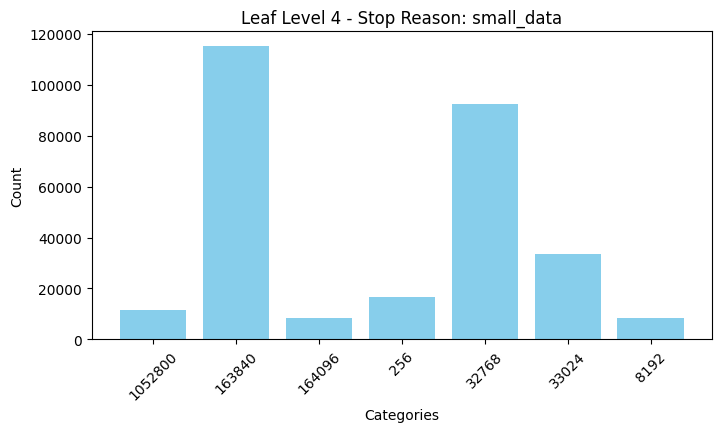


Leaf node id: dbcad07e-5af1-4b0f-a62d-7a806cff9dc9
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(1), np.int32(2), np.int32(7), np.int32(12), np.int32(15), np.int32(16), np.int32(19)}



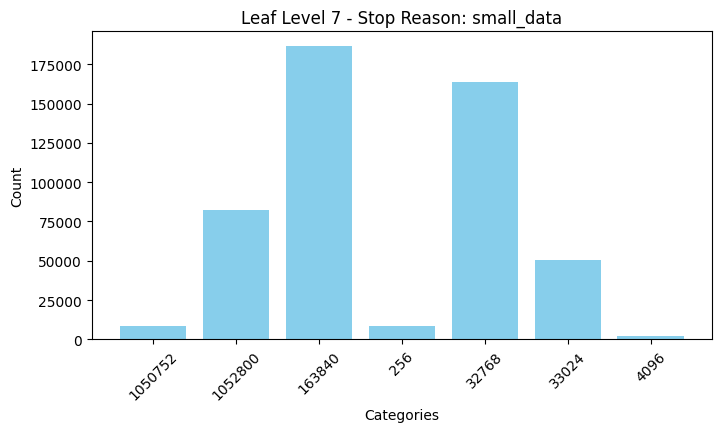


Leaf node id: 8c45f843-5621-446f-b790-6bec7fe7ae16
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(15), np.int32(16), np.int32(23)}



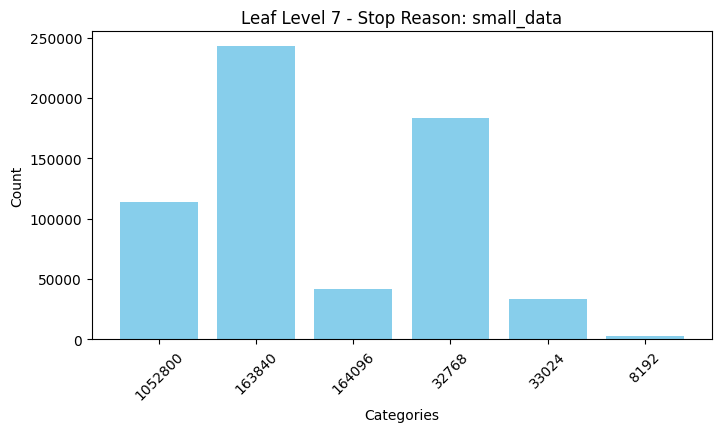


Leaf node id: d2b969de-c7f4-41f8-8af8-2b43c60add80
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(2), np.int32(7), np.int32(12), np.int32(15), np.int32(16)}



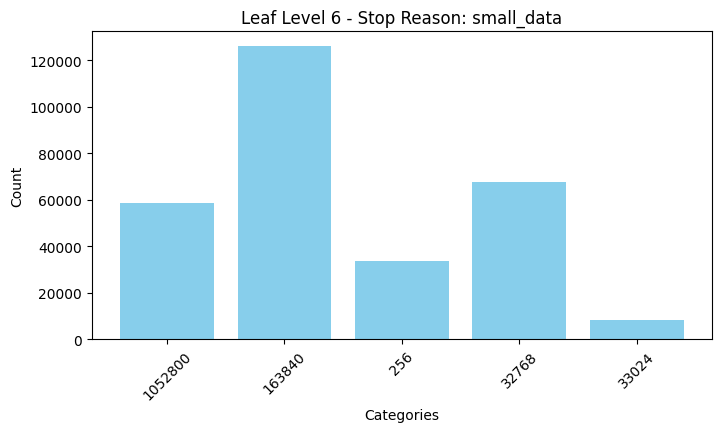


Leaf node id: d5fdec7b-8367-4fd6-bfe5-dd5332f362fc
Leaf node stop reason: small_data
Leaf node level: 5
Leaf node set: {np.int32(2), np.int32(3), np.int32(7), np.int32(8), np.int32(10), np.int32(13), np.int32(15), np.int32(16), np.int32(23)}



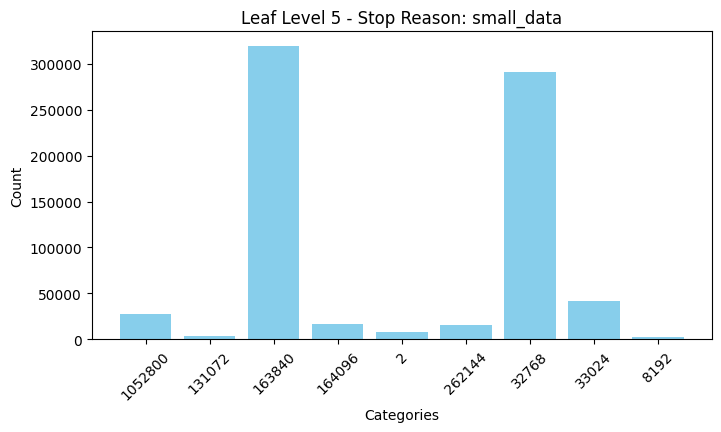


Leaf node id: e155889e-01e4-4cbf-b042-ccbb3fb504e1
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(1), np.int32(2), np.int32(7), np.int32(8), np.int32(12), np.int32(15)}



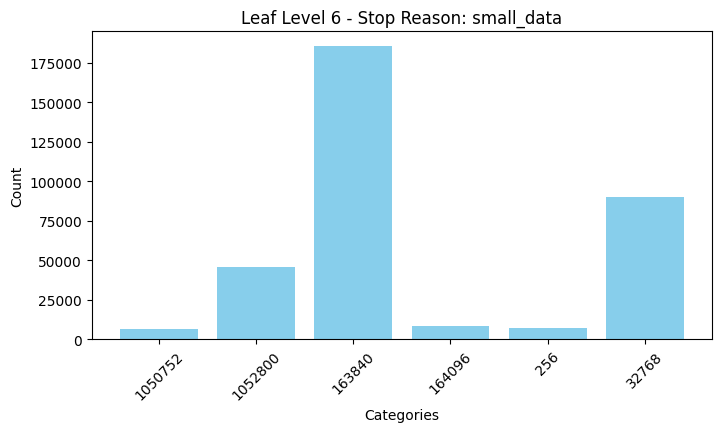


Leaf node id: 5fe6a572-f348-4e76-a335-be4467041312
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(10), np.int32(15), np.int32(16)}



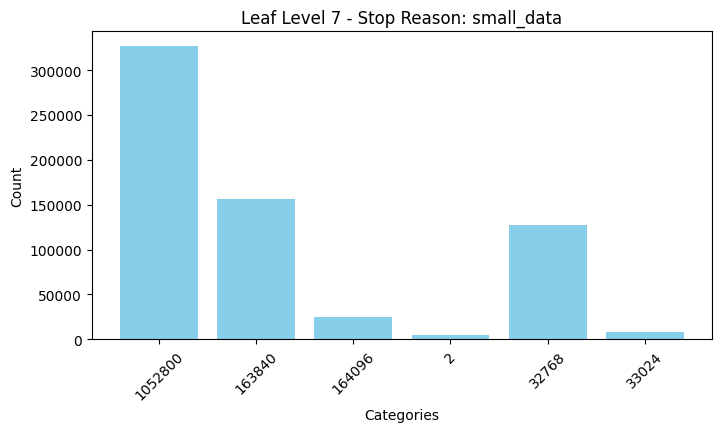


Leaf node id: 56839c30-3a0f-4de4-9c52-d4b65a279362
Leaf node stop reason: small_data
Leaf node level: 7
Leaf node set: {np.int32(2), np.int32(7), np.int32(8), np.int32(12), np.int32(15), np.int32(16)}



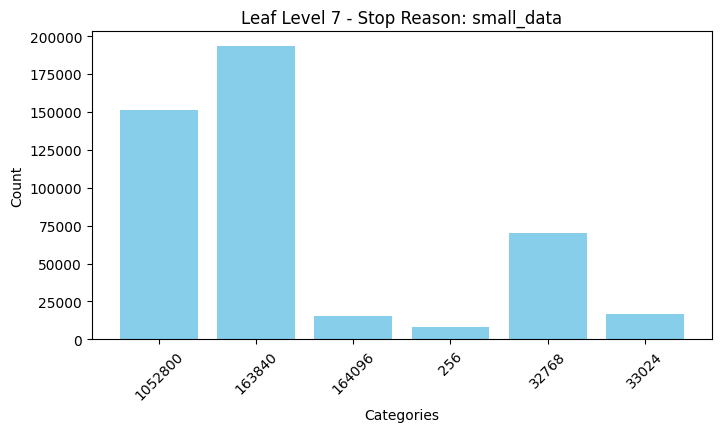


Leaf node id: 0e79af49-42aa-4461-9f40-91d89d79c3b8
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(2), np.int32(3), np.int32(7), np.int32(9), np.int32(10), np.int32(12), np.int32(13), np.int32(15), np.int32(16), np.int32(22), np.int32(23)}



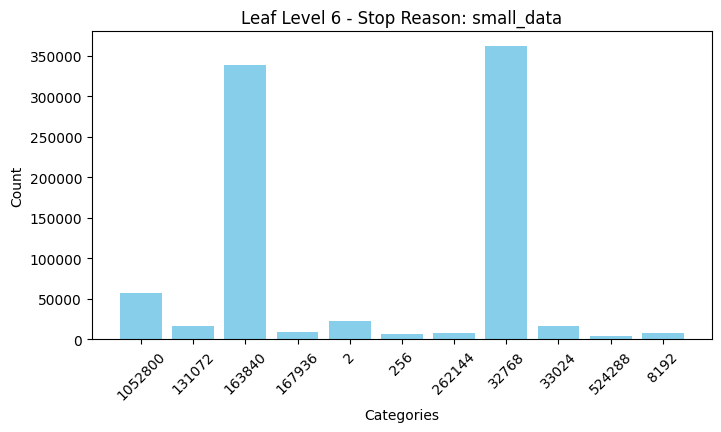


Leaf node id: 0cd88a10-1555-4706-a0a6-fbeaee4ef2fa
Leaf node stop reason: small_data
Leaf node level: 6
Leaf node set: {np.int32(2), np.int32(7), np.int32(9), np.int32(12), np.int32(15), np.int32(16), np.int32(23)}



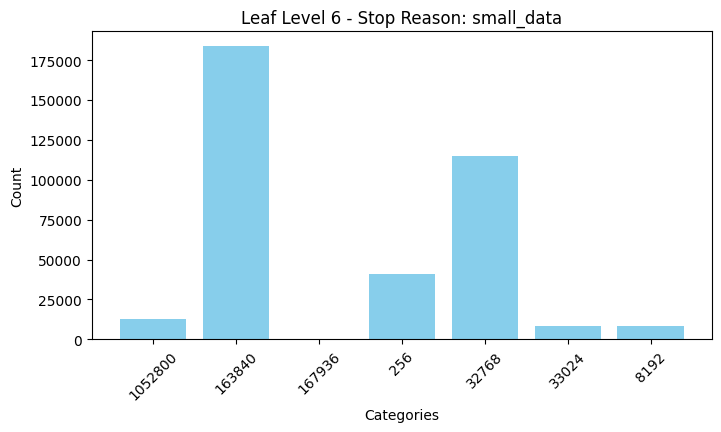


Leaf node id: 2912b37e-ef88-44b1-8b3c-c4d7a8fa1830
Leaf node stop reason: small_data
Leaf node level: 3
Leaf node set: {np.int32(6), np.int32(7), np.int32(13), np.int32(14), np.int32(15), np.int32(16)}



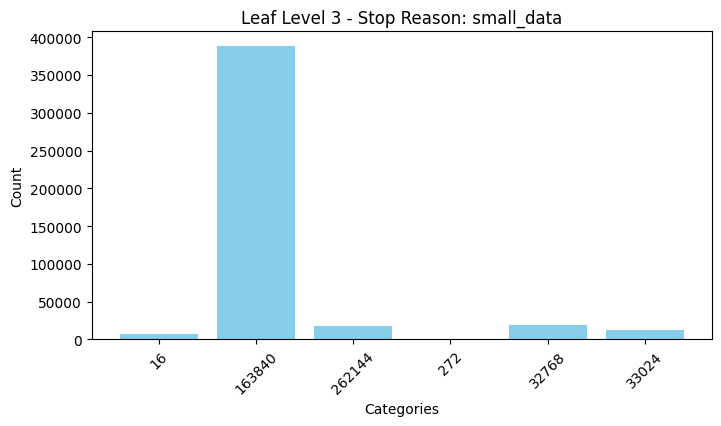


Leaf node id: e4097e96-1c11-4d3c-adfa-568b8e941b98
Leaf node stop reason: small_data
Leaf node level: 3
Leaf node set: {np.int32(0), np.int32(2), np.int32(7), np.int32(9), np.int32(15), np.int32(16), np.int32(23)}



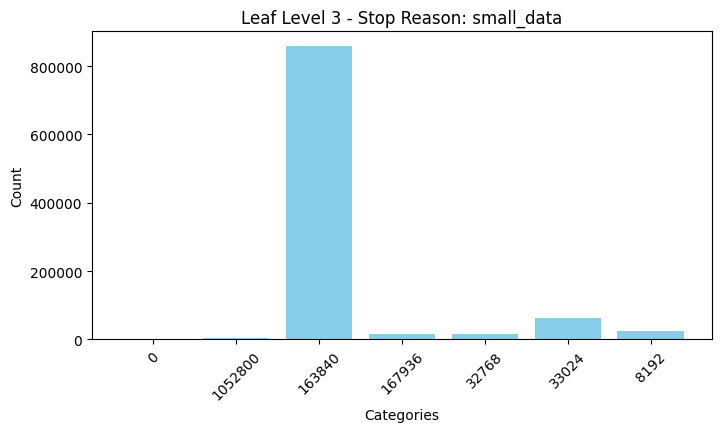


Leaf node id: 0bf8ee1c-81fb-4b25-9cef-83d0d8078f09
Leaf node stop reason: small_data
Leaf node level: 2
Leaf node set: {np.int32(8), np.int32(16), np.int32(15), np.int32(7)}



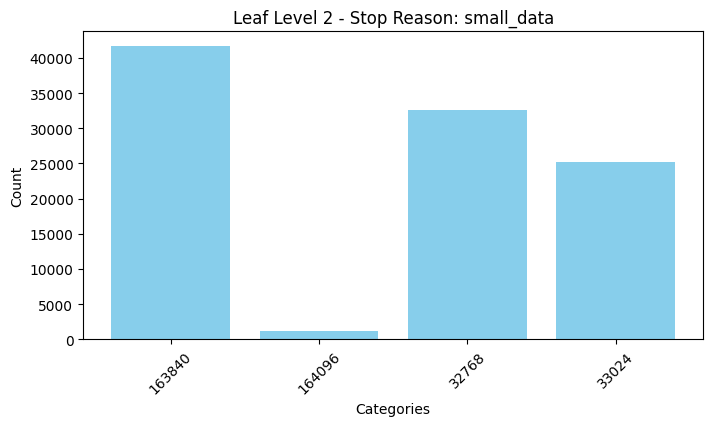

In [19]:
yesmen(tree, le)

In [14]:
def leaf_based_precision(tree, X_valid, y_valid):
    X_values = X_valid.values if hasattr(X_valid, "values") else X_valid
    total = len(y_valid)
    correct = 0

    # Traverse all samples in a loop, but avoid creating new DataFrames
    for i in range(total):
        if i % 10_000 == 0:
            print(f"Processed {i}/{total} samples...")

        x_row = X_values[i].reshape(1, -1)
        y_true = y_valid[i]

        # Traverse the tree
        node = tree
        while node["children"]:
            cluster_id = node["kmeans_model"].predict(x_row)[0]
            node = node["children"][cluster_id]

        # Check if the leaf contains the true label
        y_leaf = node["set"]
        if y_true in y_leaf:
            correct += 1

    return correct / total


In [19]:
precision = leaf_based_precision(tree, X_valid, y_valid)
print(f"Leaf-based precision: {precision:.4f}")

Processed 0/1041699 samples...
Processed 10000/1041699 samples...
Processed 20000/1041699 samples...
Processed 30000/1041699 samples...
Processed 40000/1041699 samples...
Processed 50000/1041699 samples...
Processed 60000/1041699 samples...
Processed 70000/1041699 samples...
Processed 80000/1041699 samples...
Processed 90000/1041699 samples...
Processed 100000/1041699 samples...
Processed 110000/1041699 samples...
Processed 120000/1041699 samples...
Processed 130000/1041699 samples...
Processed 140000/1041699 samples...
Processed 150000/1041699 samples...
Processed 160000/1041699 samples...
Processed 170000/1041699 samples...
Processed 180000/1041699 samples...
Processed 190000/1041699 samples...
Processed 200000/1041699 samples...
Processed 210000/1041699 samples...
Processed 220000/1041699 samples...
Processed 230000/1041699 samples...
Processed 240000/1041699 samples...
Processed 250000/1041699 samples...
Processed 260000/1041699 samples...
Processed 270000/1041699 samples...
Proces

In [15]:
# ======================================================================
# 1. SAVE TREE
# ======================================================================
def save_kmeans_tree(tree, base_path):
    """
    Saves the recursive KMeans tree into a folder structure.
    - Each node has a folder named <node_id>
    - Saves:
        - node.json: contains metadata
        - model.joblib (if kmeans_model exists)
        - data.npz (if leaf node with data)
    """

    node_id = tree["node_id"]
    node_path = os.path.join(base_path, node_id)
    os.makedirs(node_path, exist_ok=True)

    # ---------- Save metadata ----------
    metadata = {
        "level": tree["level"],
        "node_id": tree["node_id"],
        "n_samples": tree["n_samples"],
        "k": tree["k"],
        "stop_reason": tree["stop_reason"],
        "children_ids": [child["node_id"] for child in tree["children"]] if tree["children"] else [],
    }

    with open(os.path.join(node_path, "node.json"), "w") as f:
        json.dump(metadata, f, indent=4)

    # ---------- Save model ----------
    if tree["kmeans_model"] is not None:
        joblib.dump(tree["kmeans_model"], os.path.join(node_path, "model.joblib"))

    # ---------- Save data for leaf nodes ----------
    if tree["data"] is not None:
        X, y = tree["data"]
        joblib.dump((X, y), os.path.join(node_path, "data.joblib"))

    # ---------- Recursively save children ----------
    if tree["children"]:
        for child in tree["children"]:
            save_kmeans_tree(child, node_path)

    print(f"Saved node {node_id} at {node_path}")


# ======================================================================
# 2. LOAD TREE
# ======================================================================
def load_kmeans_tree(base_path):
    """
    Loads the full KMeans tree saved by save_kmeans_tree().
    Returns the tree dictionary.
    """

    # Find root (only directory at base_path)
    candidates = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    if len(candidates) != 1:
        raise ValueError("Ambiguous root folder. base_path must contain exactly one folder for the root node.")

    root_id = candidates[0]
    root_path = os.path.join(base_path, root_id)

    return _load_kmeans_tree_node(root_path)


def _load_kmeans_tree_node(node_path):
    # ---------- Load metadata ----------
    with open(os.path.join(node_path, "node.json"), "r") as f:
        metadata = json.load(f)

    node_id = metadata["node_id"]
    children_ids = metadata["children_ids"]

    # ---------- Load model ----------
    model_path = os.path.join(node_path, "model.joblib")
    model = joblib.load(model_path) if os.path.exists(model_path) else None

    # ---------- Load data ----------
    data_path = os.path.join(node_path, "data.joblib")
    if os.path.exists(data_path):
        data = joblib.load(data_path)
    else:
        data = None

    # ---------- Load children ----------
    children = []
    for cid in children_ids:
        child_path = os.path.join(node_path, cid)
        children.append(_load_kmeans_tree_node(child_path))

    # ---------- Rebuild dictionary ----------
    return {
        "level": metadata["level"],
        "node_id": node_id,
        "n_samples": metadata["n_samples"],
        "k": metadata["k"],
        "kmeans_model": model,
        "children": children,
        "stop_reason": metadata["stop_reason"],
        "data": data,
        "set": None  # optional: can be recomputed if needed
    }


# ======================================================================
# 3. LOAD DATA FOR ONE LEAF BY NODE ID
# ======================================================================
def load_leaf_data(base_path, node_id):
    """
    Loads (X, y) for a specific leaf node using its node_id.
    """

    # Walk through directories searching for node_id
    for root, dirs, files in os.walk(base_path):
        if os.path.basename(root) == node_id:
            data_path = os.path.join(root, "data.joblib")
            if not os.path.exists(data_path):
                raise ValueError(f"Node {node_id} exists but has no leaf data.")

            return joblib.load(data_path)

    raise ValueError(f"Node {node_id} not found under {base_path}.")

In [16]:
model_path = "/content/drive/Shared drives/Gestió de Projectes/Projecte/saved_model"

save_kmeans_tree(tree, model_path)

Saved node 39e70ff1-e4ca-4e26-aa38-3ed8f275e0c7 at /content/drive/Shared drives/Gestió de Projectes/Projecte/saved_model/10f65179-dd9c-4d6c-9312-e266dceec286/4cb6f42d-b934-4761-a758-fe2fc39aaf11/b7a0d59d-c9ee-4a98-99bc-fe748abc8160/aa6440b9-9ddb-407b-a976-a08b75e80ac5/9d024d59-a0e2-4e0c-a46a-8b2862df73ec/c6f08e8a-f0e5-4f92-b06c-7d7a877dc1f0/6a3fe048-dee2-4995-a80a-bee79babd559/39e70ff1-e4ca-4e26-aa38-3ed8f275e0c7
Saved node 5162d10f-0fae-4f5c-a573-d92b56191f42 at /content/drive/Shared drives/Gestió de Projectes/Projecte/saved_model/10f65179-dd9c-4d6c-9312-e266dceec286/4cb6f42d-b934-4761-a758-fe2fc39aaf11/b7a0d59d-c9ee-4a98-99bc-fe748abc8160/aa6440b9-9ddb-407b-a976-a08b75e80ac5/9d024d59-a0e2-4e0c-a46a-8b2862df73ec/c6f08e8a-f0e5-4f92-b06c-7d7a877dc1f0/6a3fe048-dee2-4995-a80a-bee79babd559/5162d10f-0fae-4f5c-a573-d92b56191f42
Saved node 6a3fe048-dee2-4995-a80a-bee79babd559 at /content/drive/Shared drives/Gestió de Projectes/Projecte/saved_model/10f65179-dd9c-4d6c-9312-e266dceec286/4cb6f42d

In [20]:
joblib.dump(le, os.path.join(model_path, "label_encoder.joblib"))

['/content/drive/Shared drives/Gestió de Projectes/Projecte/saved_model/label_encoder.joblib']